In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [33]:
df = pd.read_csv('../dataset/Mall_Customers.csv')

In [34]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [35]:
df.isnull().sum()
df.drop_duplicates(inplace=True)

In [36]:
df.columns = ["CustomerID","Gender","Age","Income","SpendingScore"]

In [37]:
df.head()

,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


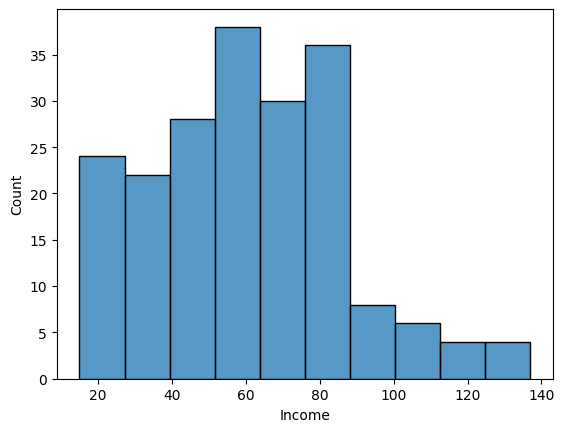

In [38]:
sns.histplot(df["Income"])
plt.show()

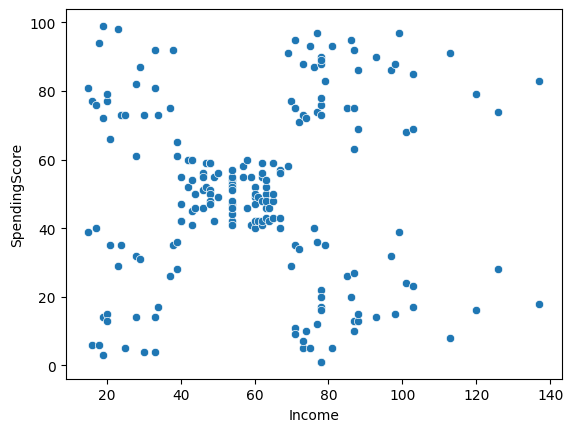

In [39]:
sns.scatterplot(x="Income",y="SpendingScore",data=df)
plt.show()

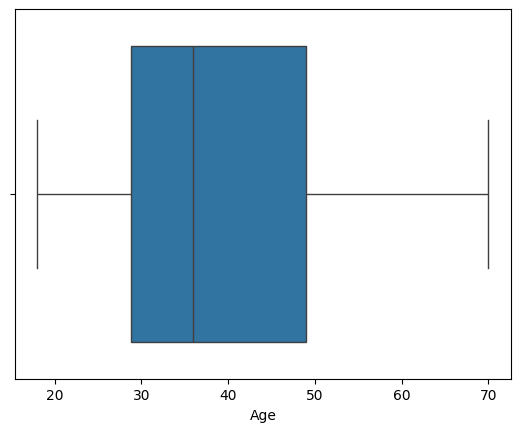

In [40]:
sns.boxplot(x=df["Age"])
plt.show()

In [41]:
X = df[["Age","Income","SpendingScore"]]

In [42]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

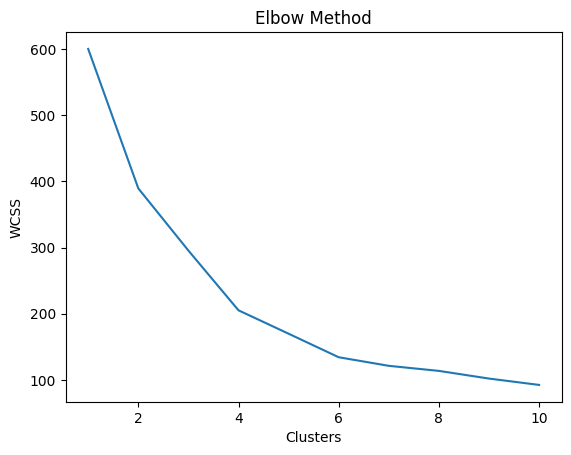

In [43]:
    
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [50]:
kmeans = KMeans(n_clusters=6, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [51]:
df.head()

,CustomerID,Gender,Age,Income,SpendingScore,Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,5
3,4,Female,23,16,77,2
4,5,Female,31,17,40,5


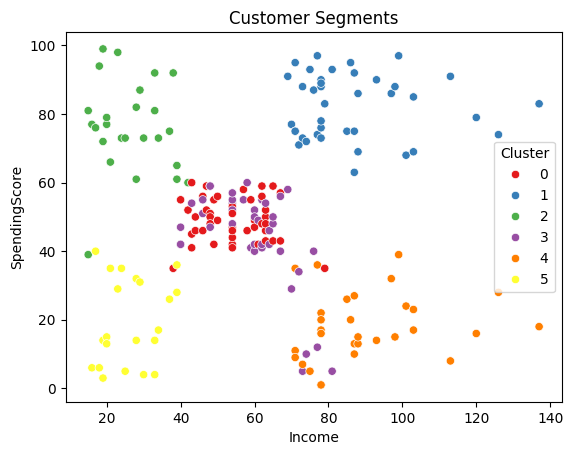

In [52]:
sns.scatterplot(
    x=df["Income"],
    y=df["SpendingScore"],
    hue=df["Cluster"],
    palette="Set1"
)

plt.title("Customer Segments")
plt.show()

In [53]:
from sklearn.metrics import silhouette_score

In [54]:
score = silhouette_score(X_scaled, df["Cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.43106526216603014


In [58]:
df.to_csv("customer_segments.csv",index=False)